In [6]:
from google.colab import files
uploaded = files.upload()

Saving insurance.csv to insurance.csv


In [7]:
import pandas as pd
df = pd.read_csv("insurance.csv")

In [8]:
print(df.head(10))

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
5   31  female  25.740         0     no  southeast   3756.62160
6   46  female  33.440         1     no  southeast   8240.58960
7   37  female  27.740         3     no  northwest   7281.50560
8   37    male  29.830         2     no  northeast   6406.41070
9   60  female  25.840         0     no  northwest  28923.13692


In [9]:
# Missing values
print(df.isnull().sum())

# Percentage
print((df.isnull().sum()/len(df))*100)

# Fill missing values if any
df.fillna(df.median(numeric_only=True), inplace=True)

# Duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
age         0.0
sex         0.0
bmi         0.0
children    0.0
smoker      0.0
region      0.0
charges     0.0
dtype: float64
Duplicate Rows: 1


In [10]:
print(df.describe())

print("Minimum:", df["charges"].min())
print("Maximum:", df["charges"].max())
print("Mean:", df["charges"].mean())
print("Median:", df["charges"].median())

               age          bmi     children       charges
count  1337.000000  1337.000000  1337.000000   1337.000000
mean     39.222139    30.663452     1.095737  13279.121487
std      14.044333     6.100468     1.205571  12110.359656
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.290000     0.000000   4746.344000
50%      39.000000    30.400000     1.000000   9386.161300
75%      51.000000    34.700000     2.000000  16657.717450
max      64.000000    53.130000     5.000000  63770.428010
Minimum: 1121.8739
Maximum: 63770.42801
Mean: 13279.121486655948
Median: 9386.1613


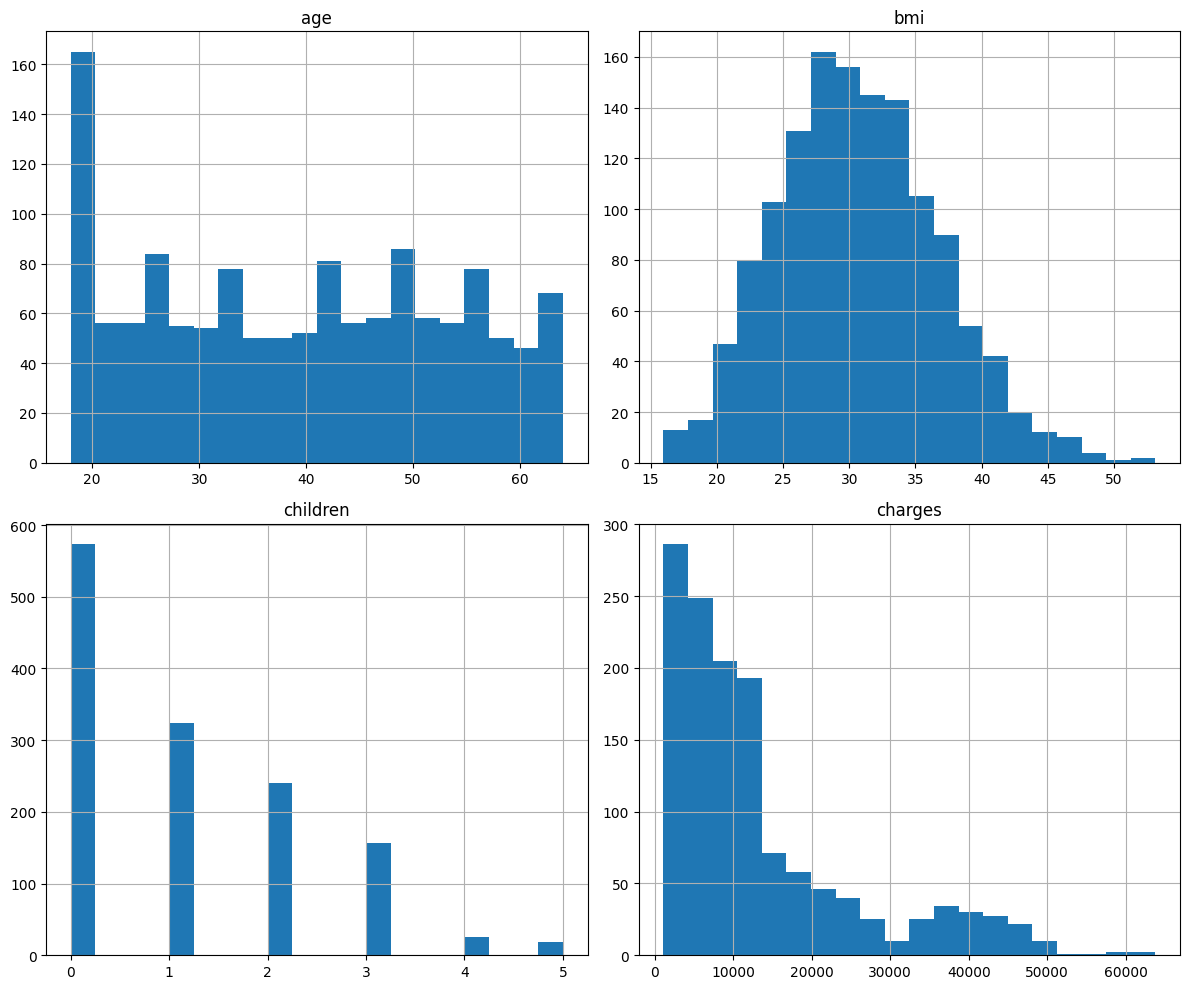

In [11]:
import matplotlib.pyplot as plt

df.hist(figsize=(12,10), bins=20)
plt.tight_layout()
plt.show()

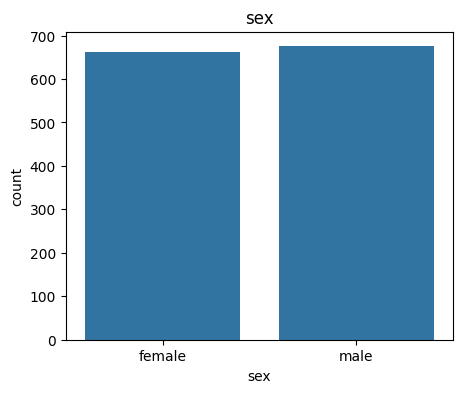

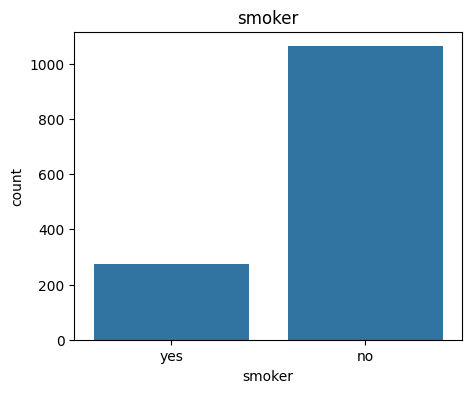

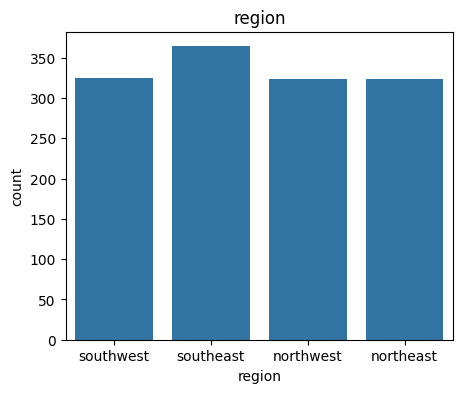

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

cat_cols = ["sex", "smoker", "region"]

for col in cat_cols:
    plt.figure(figsize=(5,4))
    sns.countplot(x=col, data=df)
    plt.title(col)
    plt.show()

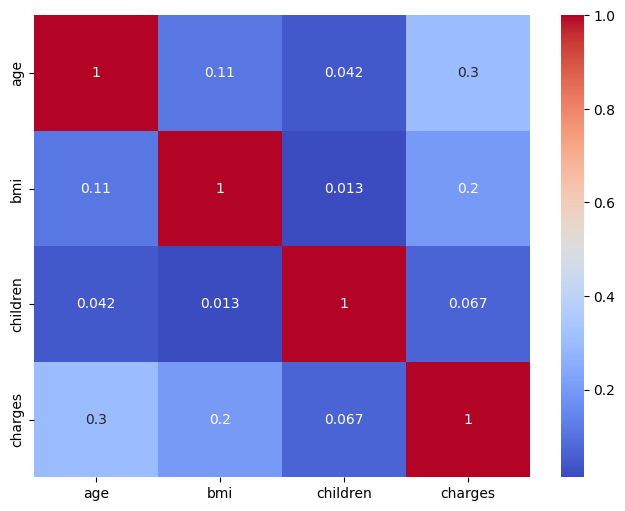

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include="number").corr(),
            annot=True,
            cmap="coolwarm")
plt.show()

In [14]:
X = df.drop("charges", axis=1)
y = df["charges"]

print("Independent Features:")
print(X.columns)

print("\nDependent Feature:")
print(y.name)

Independent Features:
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region'], dtype='object')

Dependent Feature:
charges


In [16]:
print(df[["sex","smoker"]].head())
df_encoded = pd.get_dummies(df, columns=["sex","smoker","region"], drop_first=True)

print(df_encoded.head())

      sex smoker
0  female    yes
1    male     no
2    male     no
3    male     no
4    male     no
   age     bmi  children      charges  sex_male  smoker_yes  region_northwest  \
0   19  27.900         0  16884.92400     False        True             False   
1   18  33.770         1   1725.55230      True       False             False   
2   28  33.000         3   4449.46200      True       False             False   
3   33  22.705         0  21984.47061      True       False              True   
4   32  28.880         0   3866.85520      True       False              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  


In [17]:
from sklearn.preprocessing import StandardScaler

X = df_encoded.drop("charges", axis=1)
y = df_encoded["charges"]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print(scaled_df.head())

        age       bmi  children  sex_male  smoker_yes  region_northwest  \
0 -1.440418 -0.453160 -0.909234 -1.009771    1.969660         -0.565546   
1 -1.511647  0.509422 -0.079442  0.990324   -0.507702         -0.565546   
2 -0.799350  0.383155  1.580143  0.990324   -0.507702         -0.565546   
3 -0.443201 -1.305052 -0.909234  0.990324   -0.507702          1.768203   
4 -0.514431 -0.292456 -0.909234  0.990324   -0.507702          1.768203   

   region_southeast  region_southwest  
0         -0.611638          1.764609  
1          1.634955         -0.566698  
2          1.634955         -0.566698  
3         -0.611638         -0.566698  
4         -0.611638         -0.566698  
